# Data Preparation and EDA

This notebook covers:
- Data understanding (basic inspection)
- Step 1: Data aggregation for EV market share
- Step 2: EDA, decomposition, and logit transform


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.seasonal import seasonal_decompose

plt.style.use("seaborn-v0_8")

In [6]:
df_raw = pd.read_csv("China Automobile Sales Data.csv")
df_raw.head()

,model,units_sold,make,low_price,high_price,year_month,is_ev,body_type,brand,brand_country
0,Model Y,69098,特斯拉中国,316.9,417.9,2022-11-01,EV,SUV,Tesla,United States
1,宏光MINIEV,68567,上汽通用五菱,32.8,99.9,2022-11-01,EV,Hatchback,Wuling Motors,China
2,宋PLUS新能源,64145,比亚迪,152.8,216.8,2022-11-01,EV,SUV,BYD,China
3,汉,31786,比亚迪,214.8,329.8,2022-11-01,EV,Sedan,BYD,China
4,Model 3,31193,特斯拉中国,266.7,339.9,2022-11-01,EV,Sedan,Tesla,United States


In [9]:
df_raw.info()
df_raw.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38806 entries, 0 to 38805
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   model          38806 non-null  object 
 1   units_sold     38806 non-null  int64  
 2   make           38806 non-null  object 
 3   low_price      38806 non-null  float64
 4   high_price     38806 non-null  float64
 5   year_month     38806 non-null  object 
 6   is_ev          38806 non-null  object 
 7   body_type      36440 non-null  object 
 8   brand          38806 non-null  object 
 9   brand_country  38806 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 3.0+ MB


model               0
units_sold          0
make                0
low_price           0
high_price          0
year_month          0
is_ev               0
body_type        2366
brand               0
brand_country       0
dtype: int64

In [15]:
df = df_raw.copy()

df["year_month"] = pd.to_datetime(df["year_month"], errors="coerce")
df = df.dropna(subset=["year_month"])

# Total sales each month
total_sales = (
    df.groupby("year_month")["units_sold"]
    .sum()
)

# EV sales each month
ev_sales = (
    df[df["is_ev"] == 'EV']
    .groupby("year_month")["units_sold"]
    .sum()
)

monthly = pd.concat([total_sales, ev_sales], axis=1)

monthly.columns = ["Total_Sales", "EV_Sales"]

# Fill NaN values in EV_Sales with 0 (if there were no EV sales in that month)
monthly["EV_Sales"] = monthly["EV_Sales"].fillna(0)

monthly["EV_Market_Share"] = monthly["EV_Sales"] / monthly["Total_Sales"]

monthly.head()

,Total_Sales,EV_Sales,EV_Market_Share
year_month,,,
2018-01-01,2436495,24480,0.010047
2018-02-01,1469679,23449,0.015955
2018-03-01,2144088,42745,0.019936
2018-04-01,1881043,51110,0.027171
2018-05-01,1887345,60565,0.032090


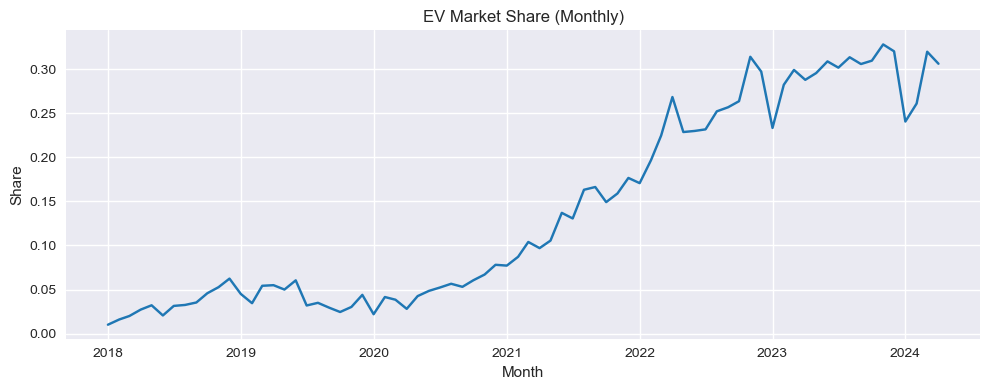

In [19]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly.index, monthly["EV_Market_Share"], color="#1f77b4")
ax.set_title("EV Market Share (Monthly)")
ax.set_ylabel("Share")
ax.set_xlabel("Month")
plt.tight_layout()
plt.show()

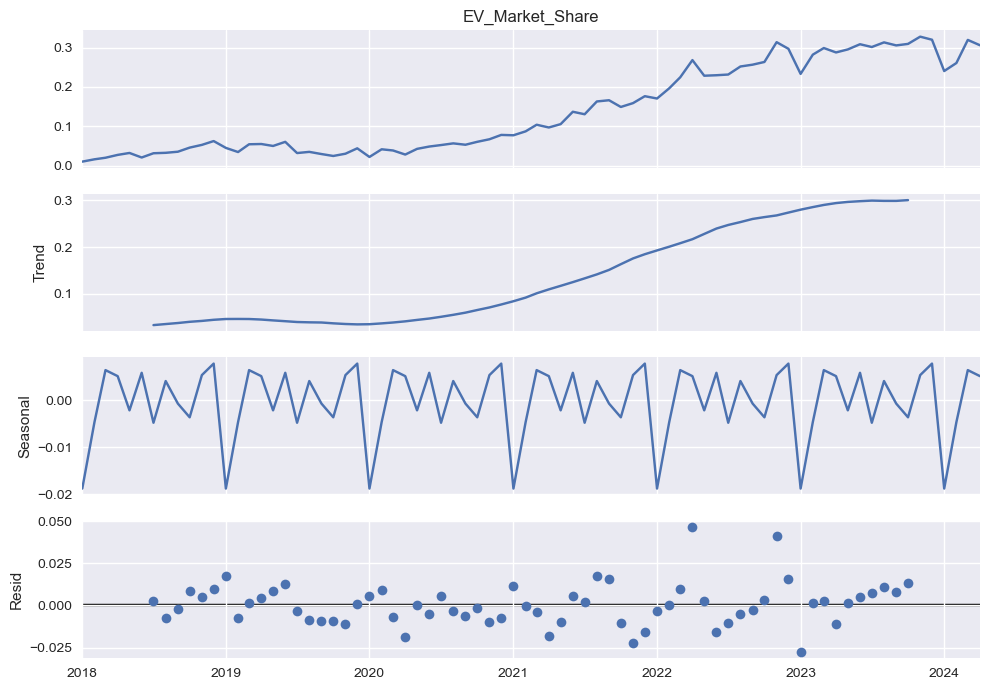

In [20]:
decomp = seasonal_decompose(
    monthly["EV_Market_Share"].dropna(),
    model="additive",
    period=12,
)

fig = decomp.plot()
fig.set_size_inches(10, 7)
plt.tight_layout()
plt.show()

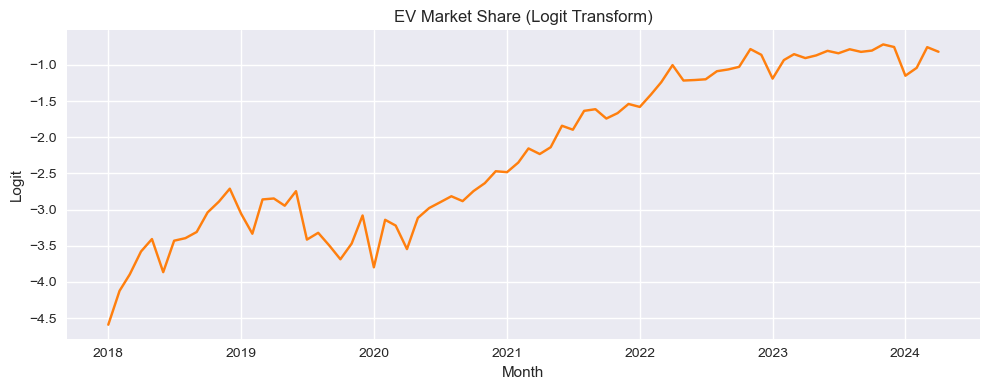

,EV_Market_Share,EV_Market_Share_Logit
year_month,,
2018-01-01,0.010047,-4.590361
2018-02-01,0.015955,-4.121888
2018-03-01,0.019936,-3.895080
2018-04-01,0.027171,-3.578054
2018-05-01,0.032090,-3.406593


In [21]:
epsilon = 1e-6
share = monthly["EV_Market_Share"].clip(epsilon, 1 - epsilon)
monthly["EV_Market_Share_Logit"] = np.log(share / (1 - share))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly.index, monthly["EV_Market_Share_Logit"], color="#ff7f0e")
ax.set_title("EV Market Share (Logit Transform)")
ax.set_ylabel("Logit")
ax.set_xlabel("Month")
plt.tight_layout()
plt.show()

monthly[["EV_Market_Share", "EV_Market_Share_Logit"]].head()

In [22]:
out_path = Path("ev_market_share.csv")
monthly.to_csv(out_path)

out_path

WindowsPath('ev_market_share.csv')